# Klasyfikacja obrazów ubrań z użyciem sieci neuronowej

Celem projektu jest zbudowanie modelu sieci neuronowej, który rozpoznaje typ ubrania na podstawie obrazu 28×28 pikseli ze zbioru Fashion-MNIST.

In [60]:
# Biblioteki do obliczeń
import numpy as np
import pandas as pd

# Biblioteki do wykresów
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras do budowy sieci neuronowych
import tensorflow as tf
from tensorflow import keras

# Podział danych na treningowe i walidacyjne
from sklearn.model_selection import train_test_split

# Metryki do ewaluacji modelu
from sklearn.metrics import confusion_matrix, classification_report

#import danych
from tensorflow.keras.datasets import fashion_mnist

# Wczytanie danych

In [61]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
#rozmiar obrazu 28x28 w train i test
#wydzielenie zbioru walidacyjnego zostanie wykonane w II części projektu

X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


# Nazwy klas

In [62]:
#zamiana numerów klas na nazwy klas -> w zbiorze defaultowo klasy opisane są jako numery
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"

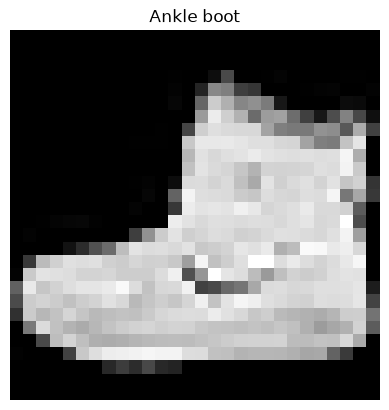

In [ ]:
#pobiera pierwszy obraz ze zbioru treningowego, pokazuje go w skali szarości (rysowanie)
plt.imshow(X_train[0], cmap="gray")
#tytuł wykresu
plt.title(class_names[y_train[0]])
#wyłącza osie wykresu
plt.axis("off")
#Publikacja
plt.show()

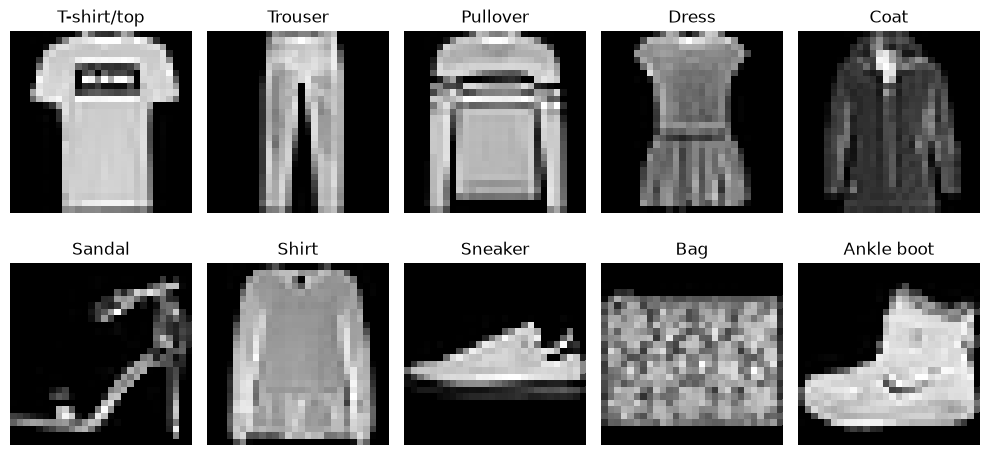

In [ ]:
#Przykładowe obrazy z każdej klasy
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))

for label in range(10):
    idx = np.where(y_train == label)[0][0]

    plt.subplot(2,5,label+1)
    plt.imshow(X_train[idx], cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()

plt.savefig("klasy_fashion_mnist.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Zakres wartości pikseli

In [65]:
print("Minimalna wartość piksela:", X_train.min())
print("Maksymalna wartość piksela:", X_train.max())

Minimalna wartość piksela: 0
Maksymalna wartość piksela: 255


# Czy zbiór zawiera brakujące dane

In [66]:
import numpy as np

print(np.isnan(X_train).sum())
print(np.isnan(X_test).sum())

0
0


# Rozkład klas

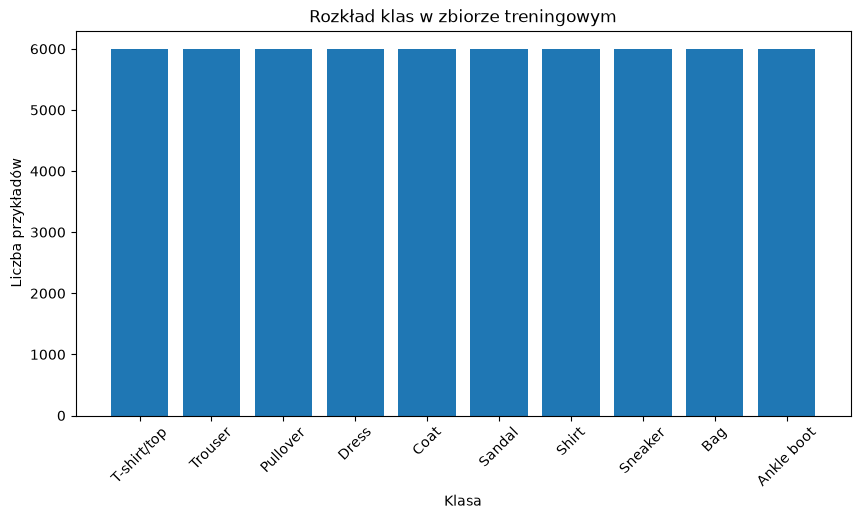

In [67]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar([class_names[i] for i in unique], counts)
plt.xticks(rotation=45)
plt.title("Rozkład klas w zbiorze treningowym")
plt.xlabel("Klasa")
plt.ylabel("Liczba przykładów")
plt.show()

# Jak wygląda średni obraz z klasy (przykład na podstawie klasy T-shirt)

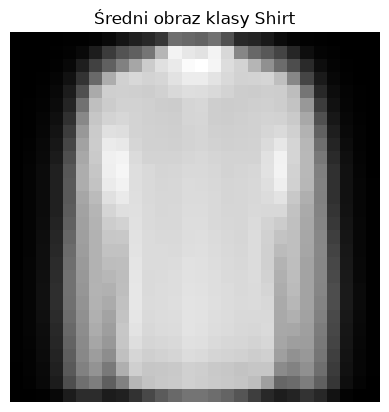

In [68]:
import numpy as np
import matplotlib.pyplot as plt

#idx = np.where(y_train == 0)
#idx = np.where(y_train == 4)
idx = np.where(y_train == 6)

mean_image = X_train[idx].mean(axis=0)

plt.imshow(mean_image, cmap="gray")
plt.title("Średni obraz klasy Shirt")
plt.axis("off")
plt.show()

Zbiór Fashion-MNIST zawiera obrazy ubrań w skali szarości o wymiarach 28×28 pikseli. 
Dane są podzielone na 60 000 przykładów treningowych oraz 10 000 przykładów testowych. Wydzielenie zbioru walidacyjnego zostanie wykonane w II części projektu.

Każdy obraz należy do jednej z 10 klas, takich jak koszulka, spodnie, sukienka, but, torba lub płaszcz. 
Wartości pikseli mieszczą się w zakresie od 0 do 255. Nie występują braki w danych.

Na podstawie rozkładu klas można zauważyć, że zbiór jest zbalansowany, ponieważ każda klasa ma podobną liczbę przykładów.

# USTAWIENIE LOSOWOŚCI

In [69]:
# Ustawiamy ziarno losowości, żeby wyniki były bardziej powtarzalne.
# Dzięki temu przy ponownym uruchomieniu notebooka wyniki powinny być podobne.

np.random.seed(42)
tf.random.set_seed(42)

# NORMALIZACJA DANYCH

In [70]:
# Obrazy w Fashion-MNIST mają wartości pikseli od 0 do 255.
# Sieci neuronowe zwykle uczą się lepiej, gdy dane wejściowe są w mniejszym zakresie.
# Dlatego dzielimy wartości pikseli przez 255, aby otrzymać zakres od 0 do 1.

X_train = X_train / 255.0
X_test = X_test / 255.0

# PODZIAŁ NA TRAIN I VALIDATION

In [71]:
# Oryginalny zbiór treningowy ma 60 000 obrazów.
# Dzielimy go na:
# - zbiór treningowy właściwy: do uczenia modelu,
# - zbiór walidacyjny: do porównywania modeli i doboru hiperparametrów.
#
# Zbiór testowy zostawiamy nietknięty do samego końca.

X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,        # 20% danych idzie na walidację
    random_state=42,      # powtarzalny podział
    stratify=y_train      # zachowuje proporcje klas w train i validation
)

# SPRAWDZENIE ROZMIARÓW ZBIORÓW

In [72]:
# Sprawdzamy, czy podział danych przebiegł poprawnie.

print("Zbiór treningowy:", X_train_part.shape)
print("Zbiór walidacyjny:", X_val.shape)
print("Zbiór testowy:", X_test.shape)

Zbiór treningowy: (48000, 28, 28)
Zbiór walidacyjny: (12000, 28, 28)
Zbiór testowy: (10000, 28, 28)


# PRZYGOTOWANIE DANYCH DLA CNN

In [ ]:
# Modele MLP (Multi-Layer Perceptron) mogą przyjmować dane w formacie:
# (liczba_obrazów, 28, 28)
# Tutaj obraz jest najpierw spłaszczany, czyli model widzi obraz jako
# jedną długą listę 784 liczb.
#
# Modele CNN potrzebują dodatkowego wymiaru kanału:
# (liczba_obrazów, 28, 28, 1)
#
# Liczba 1 oznacza, że obraz jest w skali szarości.

X_train_cnn = X_train_part.reshape(-1, 28, 28, 1)
X_val_cnn = X_val.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)
# Wartość -1 oznacza automatyczne wyliczenie liczby obrazów
# na podstawie pozostałych wymiarów.
# Dzięki temu nie trzeba ręcznie podawać liczby przykładów
# dla zbioru treningowego, walidacyjnego i testowego.

print("CNN train:", X_train_cnn.shape)
print("CNN validation:", X_val_cnn.shape)
print("CNN test:", X_test_cnn.shape)

CNN train: (48000, 28, 28, 1)
CNN validation: (12000, 28, 28, 1)
CNN test: (10000, 28, 28, 1)


# FUNKCJE POMOCNICZE
## Funkcja trenowania modelu

In [74]:
def compile_and_train(
    model,
    X_train_data,
    y_train_data,
    X_val_data,
    y_val_data,
    model_name,
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
):
    """
    Funkcja kompiluje i trenuje model.

    Parametry:
    - model: model Keras,
    - X_train_data, y_train_data: dane treningowe,
    - X_val_data, y_val_data: dane walidacyjne,
    - model_name: nazwa modelu,
    - epochs: maksymalna liczba epok,
    - batch_size: liczba przykładów w jednej paczce,
    - learning_rate: szybkość uczenia,
    - optimizer_name: nazwa optymalizatora.
    """

    print("=" * 60)
    print(f"Trenowanie modelu: {model_name}")
    print("=" * 60)

    # EarlyStopping zatrzymuje trening, jeśli val_loss nie poprawia się przez kilka epok.
    # restore_best_weights=True oznacza, że po zakończeniu treningu model wraca
    # do najlepszych wag uzyskanych na zbiorze walidacyjnym.
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    # Wybór optymalizatora.
    # Adam jest najczęściej dobrym wyborem startowym.
    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        raise ValueError("Nieznany optimizer. Użyj: adam, rmsprop albo sgd.")

    # Kompilacja modelu.
    # sparse_categorical_crossentropy stosujemy, ponieważ etykiety są liczbami 0-9,
    # a nie wektorami one-hot.
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Trenowanie modelu.
    history = model.fit(
        X_train_data,
        y_train_data,
        validation_data=(X_val_data, y_val_data),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1
    )

    return history

## Funkcja do wykresów uczenia

In [75]:
def plot_learning_curves(history, title):
    """
    Funkcja rysuje krzywe uczenia:
    - accuracy dla zbioru treningowego i walidacyjnego,
    - loss dla zbioru treningowego i walidacyjnego.
    """

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Train accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title(f"{title} - accuracy")
    plt.xlabel("Epoka")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Train loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(f"{title} - loss")
    plt.xlabel("Epoka")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

## Funkcja do zapisywania wyników

In [76]:
# Tworzymy pustą listę, do której będziemy zapisywać wyniki modeli.
results = []

def save_result(model_name, history):
    """
    Funkcja zapisuje najlepsze wyniki walidacyjne modelu.
    """

    best_val_accuracy = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])
    epochs_trained = len(history.history["loss"])

    results.append({
        "Model": model_name,
        "Best val_accuracy": best_val_accuracy,
        "Best val_loss": best_val_loss,
        "Liczba epok": epochs_trained
    })

# BASELINE

In [77]:
# Model baseline to najprostszy model referencyjny.
# Nie ma warstw ukrytych.
# Obraz 28x28 zostaje spłaszczony do wektora 784 wartości,
# a następnie od razu klasyfikowany do jednej z 10 klas.

baseline_model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(10, activation="softmax")
])

baseline_model.summary()

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_27 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu: Baseline
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 962us/step - accuracy: 0.7850 - loss: 0.6363 - val_accuracy: 0.8371 - val_loss: 0.4826
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 871us/step - accuracy: 0.8363 - loss: 0.4787 - val_accuracy: 0.8469 - val_loss: 0.4426
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 872us/step - accuracy: 0.8463 - loss: 0.4486 - val_accuracy: 0.8516 - val_loss: 0.4264
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 870us/step - accuracy: 0.8512 - loss: 0.4324 - val_accuracy: 0.8547 - val_loss: 0.4177
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 875us/step - accuracy: 0.8546 - loss: 0.4218 - val_accuracy: 0.8564 - val_loss: 0.4125
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 909us/step - accuracy: 0.8570 - loss: 0.4141 - val_accuracy: 0.8568 - val_loss: 0.4092
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 862us/step - accuracy: 0.8588 - loss: 0.4082 - val_accuracy: 0.8576 - val_loss: 0.4070
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 893

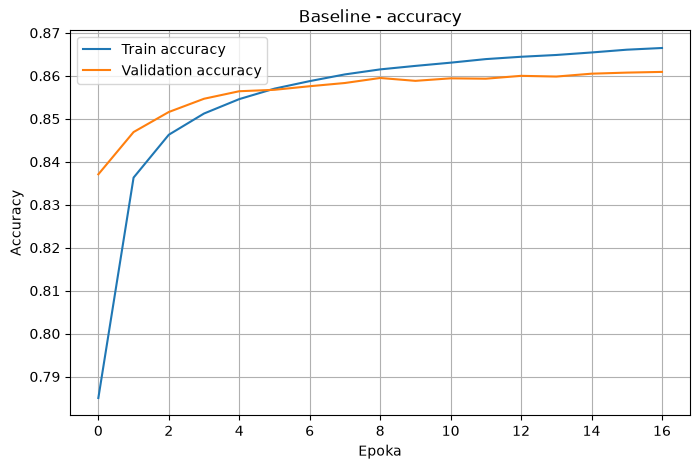

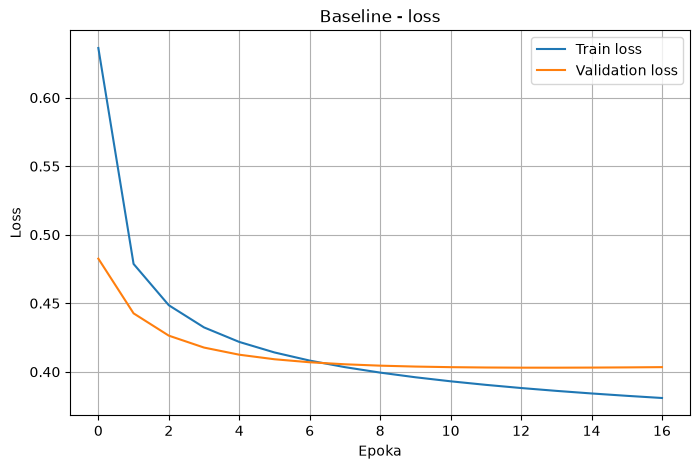

In [78]:
#Trenowanie modelu
history_baseline = compile_and_train(
    model=baseline_model,
    X_train_data=X_train_part,
    y_train_data=y_train_part,
    X_val_data=X_val,
    y_val_data=y_val,
    model_name="Baseline",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("Baseline", history_baseline)
plot_learning_curves(history_baseline, "Baseline")

# MLP 128

In [79]:
# MLP, czyli Multi-Layer Perceptron, to klasyczna sieć gęsta.
# Tutaj dodajemy jedną warstwę ukrytą z 128 neuronami.
# Funkcja ReLU pozwala modelowi uczyć się nieliniowych zależności.

mlp_128 = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

mlp_128.summary()

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_28 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu: MLP 128
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8164 - loss: 0.5206 - val_accuracy: 0.8378 - val_loss: 0.4427
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8601 - loss: 0.3884 - val_accuracy: 0.8668 - val_loss: 0.3704
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8727 - loss: 0.3491 - val_accuracy: 0.8773 - val_loss: 0.3446
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8826 - loss: 0.3221 - val_accuracy: 0.8802 - val_loss: 0.3344
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8896 - loss: 0.3036 - val_accuracy: 0.8826 - val_loss: 0.3290
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8958 - loss: 0.2858 - val_accuracy: 0.8852 - val_loss: 0.3233
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8995 - loss: 0.2732 - val_accuracy: 0.8869 - val_loss: 0.3167
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accurac

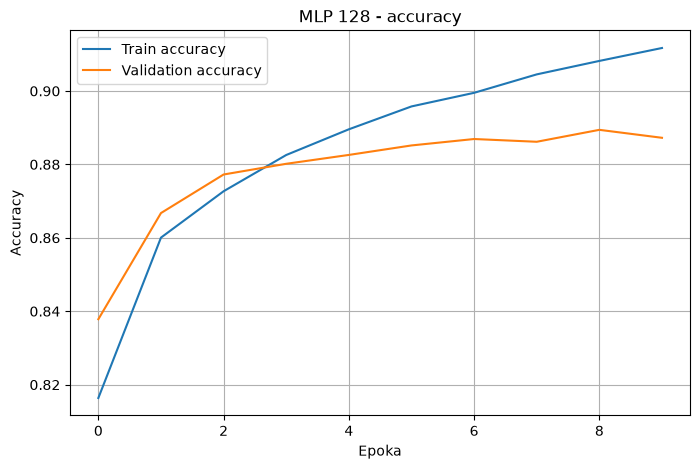

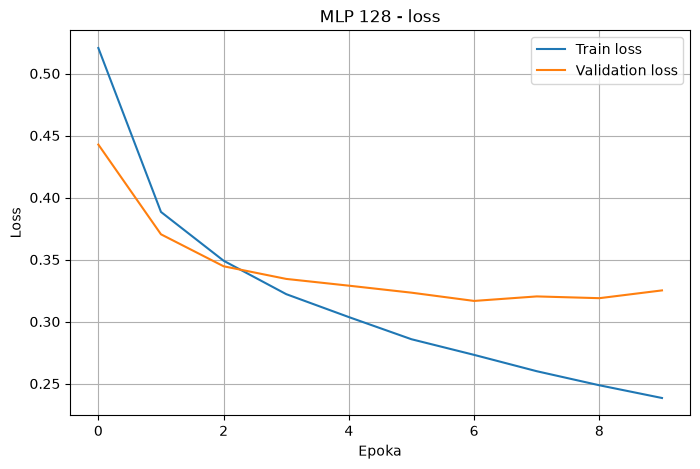

In [80]:
# Trenowanie modelu
history_mlp_128 = compile_and_train(
    model=mlp_128,
    X_train_data=X_train_part,
    y_train_data=y_train_part,
    X_val_data=X_val,
    y_val_data=y_val,
    model_name="MLP 128",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("MLP 128", history_mlp_128)
plot_learning_curves(history_mlp_128, "MLP 128")

# MLP DEEP

In [81]:
# Ten model jest głębszy od poprzedniego MLP.
# Ma dwie warstwy ukryte: 256 i 128 neuronów.
# Sprawdzamy, czy większa liczba warstw i parametrów poprawi wynik.

mlp_deep = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

mlp_deep.summary()

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_29 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu: MLP Deep
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8194 - loss: 0.4993 - val_accuracy: 0.8371 - val_loss: 0.4379
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8618 - loss: 0.3700 - val_accuracy: 0.8654 - val_loss: 0.3643
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8764 - loss: 0.3303 - val_accuracy: 0.8784 - val_loss: 0.3334
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8867 - loss: 0.3027 - val_accuracy: 0.8822 - val_loss: 0.3250
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8924 - loss: 0.2847 - val_accuracy: 0.8832 - val_loss: 0.3237
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8996 - loss: 0.2672 - val_accuracy: 0.8850 - val_loss: 0.3286
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9056 - loss: 0.2526 - val_accuracy: 0.8890 - val_loss: 0.3220
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accura

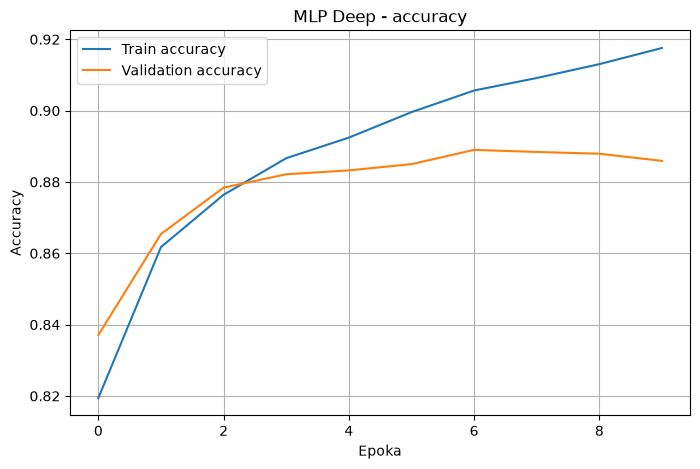

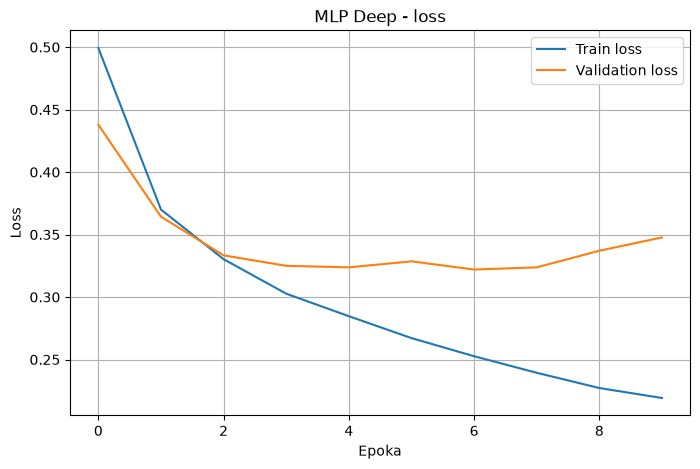

In [82]:
# Trenowanie modelu
history_mlp_deep = compile_and_train(
    model=mlp_deep,
    X_train_data=X_train_part,
    y_train_data=y_train_part,
    X_val_data=X_val,
    y_val_data=y_val,
    model_name="MLP Deep",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("MLP Deep", history_mlp_deep)
plot_learning_curves(history_mlp_deep, "MLP Deep")

# CNN

In [ ]:
# CNN, czyli Convolutional Neural Network, jest lepiej dopasowana do obrazów.
# Warstwy Conv2D uczą się lokalnych wzorców, np. krawędzi, konturów i kształtów.
# MaxPooling zmniejsza rozmiar reprezentacji i zostawia najważniejsze cechy. (2,2 jest używane najczęściej)

cnn_model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(32, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

cnn_model.summary()

Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_45 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_30 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu: CNN
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8314 - loss: 0.4681 - val_accuracy: 0.8678 - val_loss: 0.3653
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8874 - loss: 0.3083 - val_accuracy: 0.8876 - val_loss: 0.3107
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9042 - loss: 0.2595 - val_accuracy: 0.8946 - val_loss: 0.2918
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9175 - loss: 0.2252 - val_accuracy: 0.8985 - val_loss: 0.2839
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9284 - loss: 0.1963 - val_accuracy: 0.9032 - val_loss: 0.2829
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9373 - loss: 0.1704 - val_accuracy: 0.9021 - val_loss: 0.2923
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9459 - loss: 0.1481 - val_accuracy: 0.9016 - val_loss: 0.3044
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0

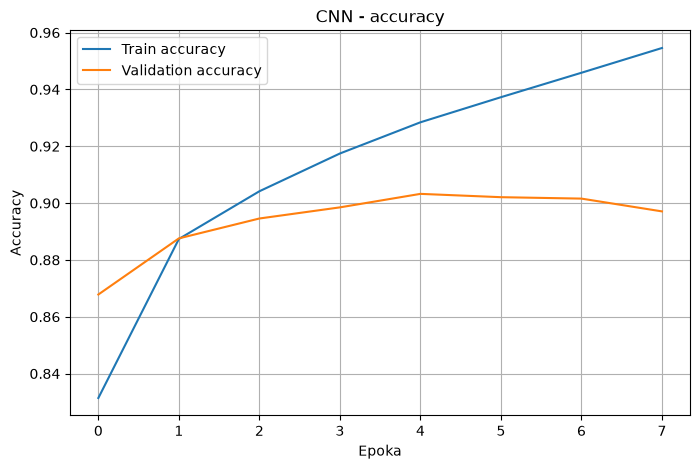

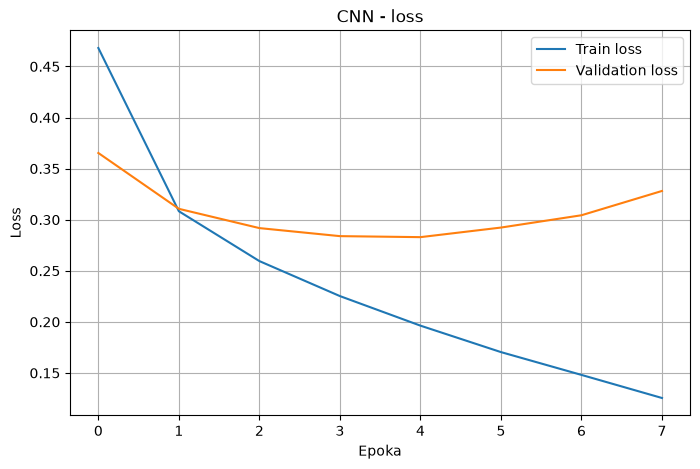

In [84]:
#Trenowanie modelu
history_cnn = compile_and_train(
    model=cnn_model,
    X_train_data=X_train_cnn,
    y_train_data=y_train_part,
    X_val_data=X_val_cnn,
    y_val_data=y_val,
    model_name="CNN",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("CNN", history_cnn)
plot_learning_curves(history_cnn, "CNN")

# CNN + DROPOUT

In [85]:
# Dropout to technika regularyzacji.
# Podczas treningu losowo wyłącza część neuronów.
# Dzięki temu model trudniej zapamiętuje dane treningowe i może lepiej generalizować.

cnn_dropout = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(32, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(10, activation="softmax")
])

cnn_dropout.summary()

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_47 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_31 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
#Trenowanie modelu

Trenowanie modelu: CNN + Dropout
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8070 - loss: 0.5276 - val_accuracy: 0.8717 - val_loss: 0.3528
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8732 - loss: 0.3478 - val_accuracy: 0.8888 - val_loss: 0.3036
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8889 - loss: 0.3008 - val_accuracy: 0.8993 - val_loss: 0.2801
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9006 - loss: 0.2703 - val_accuracy: 0.9005 - val_loss: 0.2745
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9087 - loss: 0.2452 - val_accuracy: 0.9063 - val_loss: 0.2563
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9155 - loss: 0.2241 - val_accuracy: 0.9053 - val_loss: 0.2700
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9217 - loss: 0.2056 - val_accuracy: 0.9030 - val_loss: 0.2792
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - a

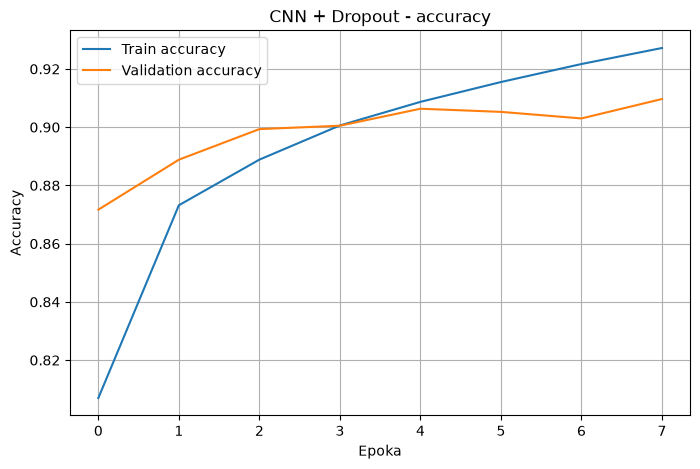

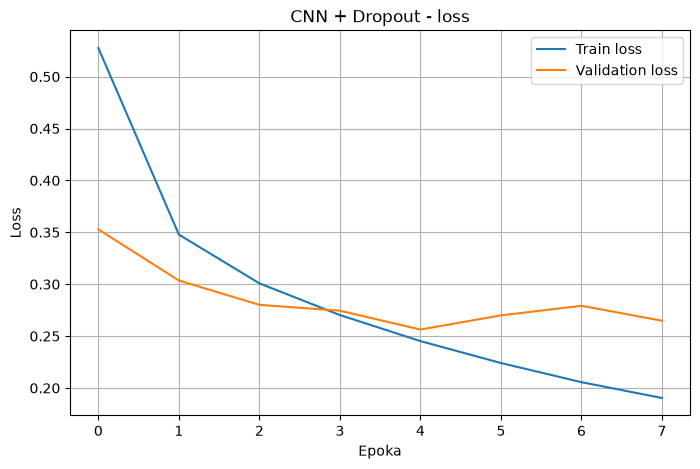

In [87]:
history_cnn_dropout = compile_and_train(
    model=cnn_dropout,
    X_train_data=X_train_cnn,
    y_train_data=y_train_part,
    X_val_data=X_val_cnn,
    y_val_data=y_val,
    model_name="CNN + Dropout",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("CNN + Dropout", history_cnn_dropout)
plot_learning_curves(history_cnn_dropout, "CNN + Dropout")

# TUNING DROPOUT

In [88]:
# Teraz sprawdzamy różne wartości Dropout.
#
# Dropout 0.2 oznacza słabszą regularyzację.
# Dropout 0.3 oznacza umiarkowaną regularyzację.
# Dropout 0.5 oznacza mocną regularyzację.
#
# Celem jest sprawdzenie, która wartość daje najlepszy wynik walidacyjny.

dropout_values = [0.2, 0.3, 0.5]

dropout_histories = {}
dropout_models = {}

In [89]:
#Trenowanie modelu
for dropout_rate in dropout_values:

    print(f"\nTest Dropout = {dropout_rate}")

    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),

        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),

        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(dropout_rate),

        keras.layers.Dense(10, activation="softmax")
    ])

    history = compile_and_train(
        model=model,
        X_train_data=X_train_cnn,
        y_train_data=y_train_part,
        X_val_data=X_val_cnn,
        y_val_data=y_val,
        model_name=f"CNN Dropout {dropout_rate}",
        epochs=20,
        batch_size=32,
        learning_rate=0.001,
        optimizer_name="adam"
    )

    dropout_histories[dropout_rate] = history
    dropout_models[dropout_rate] = model

    save_result(f"CNN Dropout {dropout_rate}", history)


Test Dropout = 0.2
Trenowanie modelu: CNN Dropout 0.2
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8126 - loss: 0.5107 - val_accuracy: 0.8683 - val_loss: 0.3587
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8773 - loss: 0.3340 - val_accuracy: 0.8888 - val_loss: 0.3007
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8956 - loss: 0.2836 - val_accuracy: 0.9002 - val_loss: 0.2721
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9070 - loss: 0.2521 - val_accuracy: 0.9059 - val_loss: 0.2623
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9163 - loss: 0.2250 - val_accuracy: 0.9002 - val_loss: 0.2758
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9250 - loss: 0.2029 - val_accuracy: 0.9119 - val_loss: 0.2521
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9311 - loss: 0.1838 - val_accuracy: 0.9097 - val_loss: 0.2619
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━

In [90]:
# Porównanie wyników dla różnych wartości Dropout.

for dropout_rate, history in dropout_histories.items():
    print(
        f"Dropout {dropout_rate}: "
        f"best val_accuracy = {max(history.history['val_accuracy']):.4f}, "
        f"best val_loss = {min(history.history['val_loss']):.4f}"
    )

Dropout 0.2: best val_accuracy = 0.9126, best val_loss = 0.2521
Dropout 0.3: best val_accuracy = 0.9162, best val_loss = 0.2636
Dropout 0.5: best val_accuracy = 0.9172, best val_loss = 0.2475


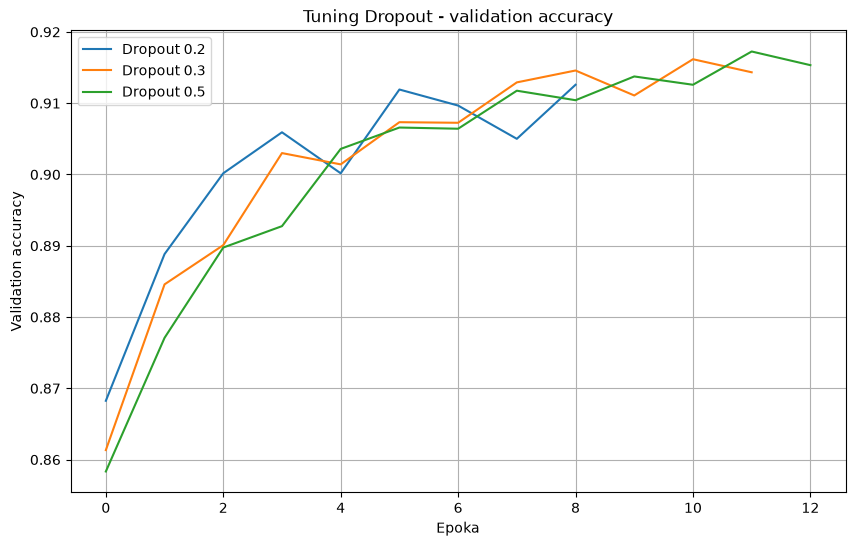

In [91]:
# Wykres porównujący krzywe walidacyjne dla różnych wartości Dropout.

plt.figure(figsize=(10, 6))

for dropout_rate, history in dropout_histories.items():
    plt.plot(
        history.history["val_accuracy"],
        label=f"Dropout {dropout_rate}"
    )

plt.title("Tuning Dropout - validation accuracy")
plt.xlabel("Epoka")
plt.ylabel("Validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

# TUNING LEARNING RATE

In [92]:
# Learning rate określa, jak duże kroki wykonuje optimizer podczas aktualizacji wag.
#
# Zbyt duży learning rate może powodować niestabilne uczenie.
# Zbyt mały learning rate może sprawić, że model będzie uczył się bardzo wolno.
#
# Sprawdzamy kilka wartości learning rate:
# 0.01, 0.001, 0.0001, 0.0005

learning_rates = [0.01, 0.001, 0.0005, 0.0001]

lr_histories = {}
lr_models = {}

In [93]:
#Trening modelu
for lr in learning_rates:

    print(f"\nTest learning rate = {lr}")

    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),

        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),

        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),

        keras.layers.Dense(10, activation="softmax")
    ])

    history = compile_and_train(
        model=model,
        X_train_data=X_train_cnn,
        y_train_data=y_train_part,
        X_val_data=X_val_cnn,
        y_val_data=y_val,
        model_name=f"CNN LR {lr}",
        epochs=20,
        batch_size=32,
        learning_rate=lr,
        optimizer_name="adam"
    )

    lr_histories[lr] = history
    lr_models[lr] = model

    save_result(f"CNN LR {lr}", history)


Test learning rate = 0.01
Trenowanie modelu: CNN LR 0.01
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8037 - loss: 0.5368 - val_accuracy: 0.8459 - val_loss: 0.4049
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8439 - loss: 0.4217 - val_accuracy: 0.8602 - val_loss: 0.3785
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8503 - loss: 0.4002 - val_accuracy: 0.8563 - val_loss: 0.3851
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8539 - loss: 0.3994 - val_accuracy: 0.8685 - val_loss: 0.3617
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8564 - loss: 0.3860 - val_accuracy: 0.8627 - val_loss: 0.3795
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8581 - loss: 0.3826 - val_accuracy: 0.8691 - val_loss: 0.3657
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8602 - loss: 0.3820 - val_accuracy: 0.8734 - val_loss: 0.3686

Test learning rate = 0.001
Tren

In [94]:
# Porównanie learning rate.

for lr, history in lr_histories.items():
    print(
        f"Learning rate {lr}: "
        f"best val_accuracy = {max(history.history['val_accuracy']):.4f}, "
        f"best val_loss = {min(history.history['val_loss']):.4f}"
    )

Learning rate 0.01: best val_accuracy = 0.8734, best val_loss = 0.3617
Learning rate 0.001: best val_accuracy = 0.9142, best val_loss = 0.2601
Learning rate 0.0005: best val_accuracy = 0.9151, best val_loss = 0.2432
Learning rate 0.0001: best val_accuracy = 0.9035, best val_loss = 0.2623


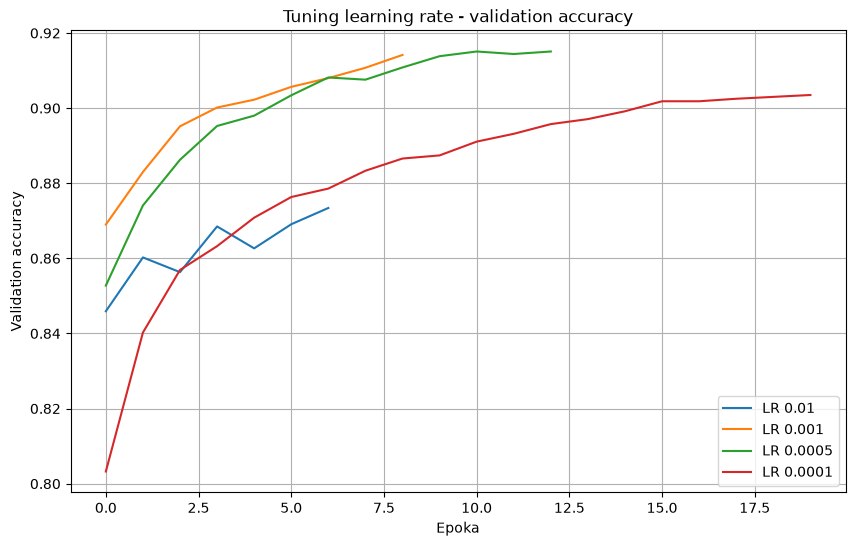

In [95]:
plt.figure(figsize=(10, 6))

for lr, history in lr_histories.items():
    plt.plot(
        history.history["val_accuracy"],
        label=f"LR {lr}"
    )

plt.title("Tuning learning rate - validation accuracy")
plt.xlabel("Epoka")
plt.ylabel("Validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

# TUNING OPTIMIZER

In [ ]:
# Teraz porównujemy różne optymalizatory.
#
# Adam - najpopularniejszy optymalizator.
# Automatycznie dostosowuje szybkość uczenia dla poszczególnych wag,
# dzięki czemu zwykle szybko osiąga dobre wyniki.

# RMSprop - modyfikuje learning rate na podstawie wcześniejszych gradientów.
# Dobrze radzi sobie w sieciach neuronowych i często zapewnia stabilne uczenie.

# SGD (Stochastic Gradient Descent) - klasyczna metoda aktualizacji wag.
# Wykonuje prosty krok w kierunku minimum funkcji straty.
# Jest bardziej wrażliwy na dobór learning rate, ale bywa skuteczny
# i pozwala lepiej zrozumieć proces optymalizacji.

optimizers = {
    "adam": 0.001, #domyślna wartość
    "rmsprop": 0.001, #sam dostosowuje wartości dla każdej wagi, więc nie potrzebuje wyższej wartości
    "sgd": 0.01 #mniejsze wartości są zbyt małe i uczenie przebiega zbyt długo
}

optimizer_histories = {}
optimizer_models = {}

In [97]:
#Trenowanie
for optimizer_name, lr in optimizers.items():

    print(f"\nTest optimizer = {optimizer_name}, learning rate = {lr}")

    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),

        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),

        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),

        keras.layers.Dense(10, activation="softmax")
    ])

    history = compile_and_train(
        model=model,
        X_train_data=X_train_cnn,
        y_train_data=y_train_part,
        X_val_data=X_val_cnn,
        y_val_data=y_val,
        model_name=f"CNN optimizer {optimizer_name}",
        epochs=20,
        batch_size=32,
        learning_rate=lr,
        optimizer_name=optimizer_name
    )

    optimizer_histories[optimizer_name] = history
    optimizer_models[optimizer_name] = model

    save_result(f"CNN optimizer {optimizer_name}", history)


Test optimizer = adam, learning rate = 0.001
Trenowanie modelu: CNN optimizer adam
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8073 - loss: 0.5308 - val_accuracy: 0.8664 - val_loss: 0.3651
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8714 - loss: 0.3529 - val_accuracy: 0.8883 - val_loss: 0.3024
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8891 - loss: 0.3041 - val_accuracy: 0.8944 - val_loss: 0.2825
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9010 - loss: 0.2696 - val_accuracy: 0.8990 - val_loss: 0.2722
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9099 - loss: 0.2440 - val_accuracy: 0.9035 - val_loss: 0.2657
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9171 - loss: 0.2225 - val_accuracy: 0.9093 - val_loss: 0.2612
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9216 - loss: 0.2051 - val_accuracy: 0.9077 - val_loss: 0.2596
Epoch 

In [98]:
# Porównanie optymalizatorów.

for optimizer_name, history in optimizer_histories.items():
    print(
        f"Optimizer {optimizer_name}: "
        f"best val_accuracy = {max(history.history['val_accuracy']):.4f}, "
        f"best val_loss = {min(history.history['val_loss']):.4f}"
    )

Optimizer adam: best val_accuracy = 0.9106, best val_loss = 0.2596
Optimizer rmsprop: best val_accuracy = 0.8982, best val_loss = 0.2927
Optimizer sgd: best val_accuracy = 0.8765, best val_loss = 0.3388


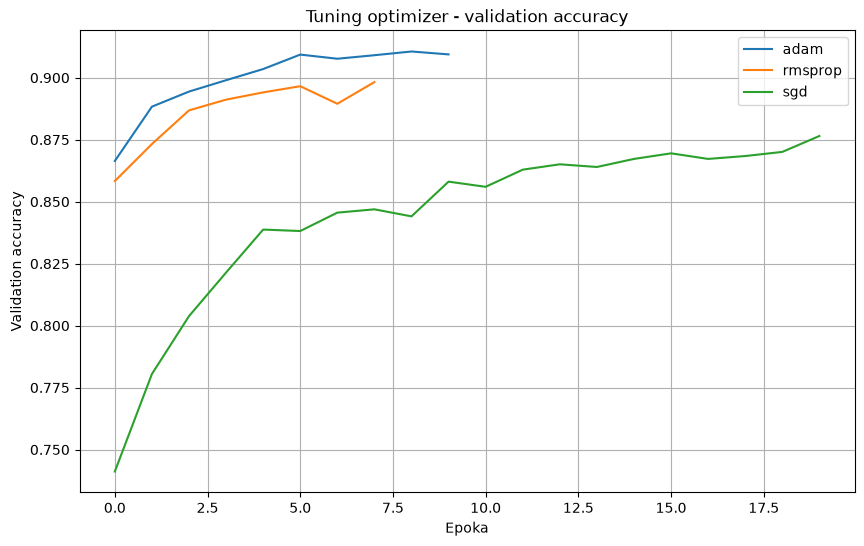

In [99]:
plt.figure(figsize=(10, 6))

for optimizer_name, history in optimizer_histories.items():
    plt.plot(
        history.history["val_accuracy"],
        label=optimizer_name
    )

plt.title("Tuning optimizer - validation accuracy")
plt.xlabel("Epoka")
plt.ylabel("Validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

# CNN + AUGMENTATION

In [ ]:
# Augmentacja danych polega na losowej modyfikacji obrazów podczas treningu.
# Dzięki temu model widzi bardziej zróżnicowane przykłady.
#
# W tym przypadku używamy:
# - lekkiego przesunięcia,
# - lekkiego obrotu,
# - lekkiego przybliżenia.
#
# Nie stosujemy bardzo agresywnej augmentacji, bo obrazy są małe: 28x28 pikseli.

data_augmentation = keras.Sequential([
    keras.layers.RandomTranslation(0.08, 0.08),
    keras.layers.RandomRotation(0.08),
    keras.layers.RandomZoom(0.1)
])

In [ ]:
# Model CNN z augmentacją danych.
# Augmentacja działa tylko podczas treningu.
# Podczas walidacji i testowania obrazy nie są losowo zmieniane. Celem jest sztuczne zwiększenie różnorodności danych treningowych, a nie utrudnianie oceny modelu.

cnn_augmentation = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),

    data_augmentation,

    keras.layers.Conv2D(32, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(10, activation="softmax")
])

cnn_augmentation.summary()

Model: "sequential_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_49 (Sequential)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_68 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_69 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_42 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu: CNN + Augmentation
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6946 - loss: 0.8101 - val_accuracy: 0.7644 - val_loss: 0.6367
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7653 - loss: 0.6123 - val_accuracy: 0.8027 - val_loss: 0.5225
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7946 - loss: 0.5474 - val_accuracy: 0.8142 - val_loss: 0.4916
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8098 - loss: 0.5061 - val_accuracy: 0.8247 - val_loss: 0.4675
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8213 - loss: 0.4783 - val_accuracy: 0.8467 - val_loss: 0.4277
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8269 - loss: 0.4575 - val_accuracy: 0.8403 - val_loss: 0.4543
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8351 - loss: 0.4416 - val_accuracy: 0.8430 - val_loss: 0.4328
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/ste

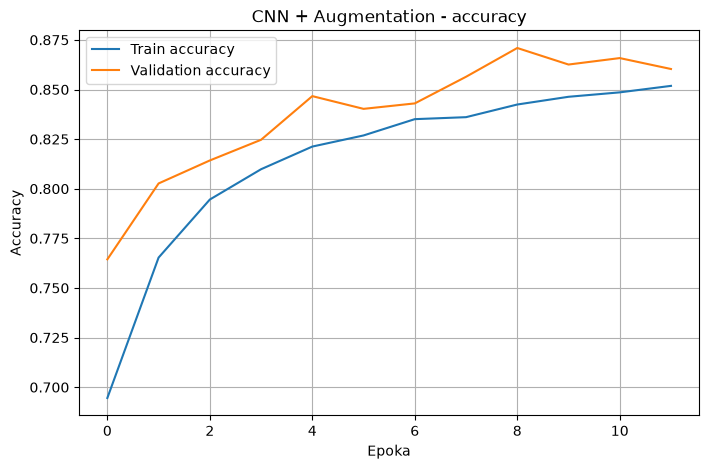

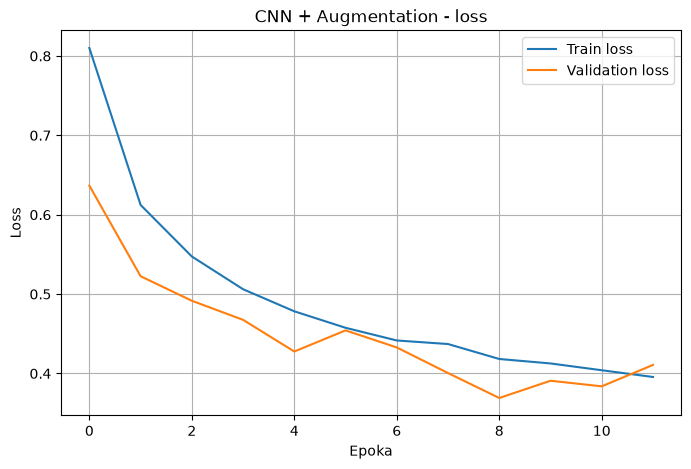

In [102]:
#Trenowanie
history_cnn_augmentation = compile_and_train(
    model=cnn_augmentation,
    X_train_data=X_train_cnn,
    y_train_data=y_train_part,
    X_val_data=X_val_cnn,
    y_val_data=y_val,
    model_name="CNN + Augmentation",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("CNN + Augmentation", history_cnn_augmentation)
plot_learning_curves(history_cnn_augmentation, "CNN + Augmentation")

# CNN + BATCH NORMALIZATION

In [ ]:
# BatchNormalization normalizuje aktywacje wewnątrz sieci. Dla każdego batcha oblicza: średnią i odchylenie standardowe i przekształca aktywacje tak, 
# aby miały w przybliżeniu: średnia = 0, odchylenie = 1.
# Sabilizuje to trening i przyspiesza uczenie.
# Często stosuje się ją w kolejnych warstwach.

cnn_batchnorm = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(32, (3, 3), activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(128, (3, 3), activation="relu"),
    keras.layers.BatchNormalization(),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.4),

    keras.layers.Dense(10, activation="softmax")
])

cnn_batchnorm.summary()

Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_71 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_70 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_71 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_43 (Flatten)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,442 (947.04 KB)

 Trainable params: 241,994 (945.29 KB)

 Non-trainable params: 448 (1.75 KB)

Trenowanie modelu: CNN + BatchNormalization
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8228 - loss: 0.5010 - val_accuracy: 0.8724 - val_loss: 0.3530
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8763 - loss: 0.3358 - val_accuracy: 0.8841 - val_loss: 0.3167
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8941 - loss: 0.2893 - val_accuracy: 0.8952 - val_loss: 0.2954
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9054 - loss: 0.2556 - val_accuracy: 0.9032 - val_loss: 0.2859
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9148 - loss: 0.2293 - val_accuracy: 0.9027 - val_loss: 0.2862
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9220 - loss: 0.2076 - val_accuracy: 0.9053 - val_loss: 0.2965
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9299 - loss: 0.1856 - val_accuracy: 0.9086 - val_loss: 0.2917


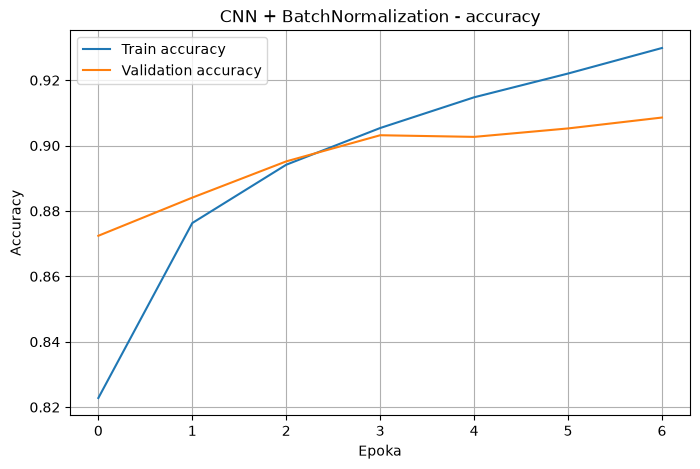

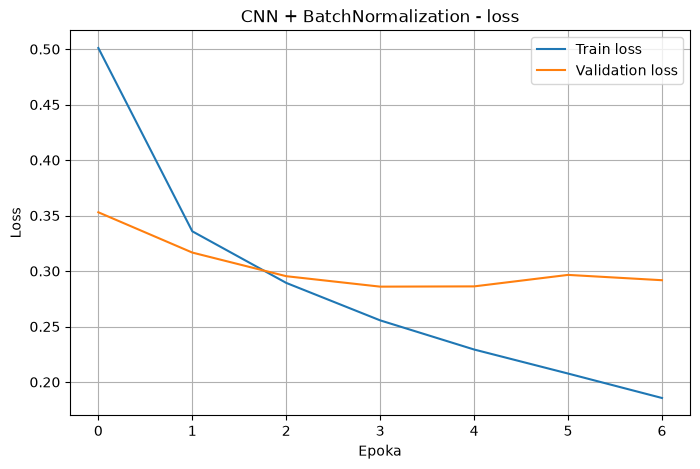

In [ ]:
#Trening
history_cnn_batchnorm = compile_and_train(
    model=cnn_batchnorm,
    X_train_data=X_train_cnn,
    y_train_data=y_train_part,
    X_val_data=X_val_cnn,
    y_val_data=y_val,
    model_name="CNN + BatchNormalization",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("CNN + BatchNormalization", history_cnn_batchnorm)
plot_learning_curves(history_cnn_batchnorm, "CNN + BatchNormalization")

# ZBIORCZY TUNING KOMBINACJI HIPERPARAMETRÓW

In [105]:
def build_cnn_combo_model(dropout_rate=0.5, use_augmentation=False):
    """
    Funkcja tworzy model CNN używany w końcowym tuningu kombinacji hiperparametrów.

    Parametry:
    - dropout_rate: wartość Dropout,
    - use_augmentation: czy model ma zawierać augmentację danych.

    Dzięki tej funkcji możemy łatwo tworzyć kilka modeli
    o tej samej architekturze, ale z różnymi ustawieniami.
    """

    layers = [
        keras.layers.Input(shape=(28, 28, 1))
    ]

    # Augmentacja danych jest dodawana tylko wtedy,
    # gdy use_augmentation=True.
    #
    # Augmentacja działa podczas treningu i tworzy lekko zmienione wersje obrazów.
    # Pomaga to ograniczyć przeuczenie modelu.
    if use_augmentation:
        layers.append(
            keras.Sequential([
                keras.layers.RandomTranslation(0.08, 0.08),
                keras.layers.RandomRotation(0.08),
                keras.layers.RandomZoom(0.1)
            ])
        )

    # Pierwszy blok konwolucyjny.
    # Conv2D uczy się lokalnych cech obrazu, np. krawędzi i prostych kształtów.
    layers.append(
        keras.layers.Conv2D(
            32,
            (3, 3),
            activation="relu"
        )
    )

    # MaxPooling zmniejsza rozmiar map cech,
    # zostawiając najważniejsze informacje.
    layers.append(
        keras.layers.MaxPooling2D((2, 2))
    )

    # Drugi blok konwolucyjny.
    # Większa liczba filtrów pozwala wykrywać bardziej złożone wzorce.
    layers.append(
        keras.layers.Conv2D(
            64,
            (3, 3),
            activation="relu"
        )
    )

    layers.append(
        keras.layers.MaxPooling2D((2, 2))
    )

    # Spłaszczenie map cech do wektora.
    layers.append(
        keras.layers.Flatten()
    )

    # Warstwa Dense uczy się klasyfikacji na podstawie cech wyciągniętych przez CNN.
    layers.append(
        keras.layers.Dense(
            128,
            activation="relu"
        )
    )

    # Dropout ogranicza przeuczenie.
    layers.append(
        keras.layers.Dropout(dropout_rate)
    )

    # Warstwa wyjściowa.
    # Softmax zwraca prawdopodobieństwa dla 10 klas.
    layers.append(
        keras.layers.Dense(
            10,
            activation="softmax"
        )
    )

    model = keras.Sequential(layers)

    return model

## Lista końcowych kombinacji

In [106]:
# Na podstawie wcześniejszych eksperymentów wybrano najbardziej obiecujące wartości:
#
# - Dropout: 0.5 dał najlepszy wynik w osobnym teście.
# - Learning rate: 0.001 i 0.0005 osiągnęły najlepsze wyniki.
# - Optimizer: Adam był najlepszy, ale RMSprop również zostaje sprawdzony kontrolnie.
# - Augmentation: sprawdzamy warianty z augmentacją i bez augmentacji.
#
# Nie testujemy SGD, learning rate 0.01 ani 0.0001,
# ponieważ we wcześniejszych wynikach były wyraźnie słabsze.

combo_settings = [

    # 1. Najlepszy dropout + najlepszy learning rate + Adam, bez augmentacji
    {"dropout": 0.5, "lr": 0.001,  "optimizer": "adam", "augmentation": False},

    # 2. To samo, ale z augmentacją
    {"dropout": 0.5, "lr": 0.001,  "optimizer": "adam", "augmentation": True},

    # 3. Adam z mniejszym learning rate, bez augmentacji
    {"dropout": 0.5, "lr": 0.0005, "optimizer": "adam", "augmentation": False},

    # 4. Adam z mniejszym learning rate i augmentacją
    {"dropout": 0.5, "lr": 0.0005, "optimizer": "adam", "augmentation": True},

    # 5. Sprawdzenie, czy mniejszy Dropout 0.3 lepiej współpracuje z augmentacją
    {"dropout": 0.3, "lr": 0.001,  "optimizer": "adam", "augmentation": True},

    # 6. Sprawdzenie jeszcze słabszej regularyzacji Dropout 0.2 z augmentacją
    {"dropout": 0.2, "lr": 0.001,  "optimizer": "adam", "augmentation": True},

    # 7. RMSprop jako alternatywa dla Adama przy najlepszym Dropout i augmentacji
    {"dropout": 0.5, "lr": 0.001,  "optimizer": "rmsprop", "augmentation": True},

    # 8. RMSprop z mniejszym learning rate
    {"dropout": 0.5, "lr": 0.0005, "optimizer": "rmsprop", "augmentation": True}
]

## Trenowanie modeli z kombinacjami

In [107]:
# Słowniki do zapisania historii treningu i modeli.
# Dzięki temu po treningu będzie można porównać wyniki
# oraz wybrać najlepszy model.

combo_histories = {}
combo_models = {}
combo_results = []

In [ ]:
for i, params in enumerate(combo_settings, start=1):

    # Pobieramy wartości hiperparametrów z aktualnej konfiguracji.
    dropout_rate = params["dropout"]
    lr = params["lr"]
    optimizer_name = params["optimizer"]
    use_augmentation = params["augmentation"]

    # Tworzymy czytelną nazwę modelu.
    model_name = (
        f"Combo {i}: "
        f"dropout={dropout_rate}, "
        f"lr={lr}, "
        f"opt={optimizer_name}, "
        f"aug={use_augmentation}"
    )

    print("=" * 90)
    print(model_name)
    print("=" * 90)

    # Dla każdej kombinacji tworzymy nowy model od zera.
    # ponieważ każdy eksperyment powinien startować
    # od nowej inicjalizacji wag.
    model = build_cnn_combo_model(
        dropout_rate=dropout_rate,
        use_augmentation=use_augmentation
    )

    # Trenujemy model dla aktualnej kombinacji hiperparametrów.
    history = compile_and_train(
        model=model,
        X_train_data=X_train_cnn,
        y_train_data=y_train_part,
        X_val_data=X_val_cnn,
        y_val_data=y_val,
        model_name=model_name,
        epochs=20,
        batch_size=32, # 32 daje stabilność uczenia + rozsądne zużycie pamięci + dobra szybkość treningu
        learning_rate=lr,
        optimizer_name=optimizer_name
    )

    # Zapisujemy historię treningu i model.
    combo_histories[model_name] = history
    combo_models[model_name] = model

    # Zbieramy najważniejsze wyniki do osobnej tabeli.
    best_val_accuracy = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])
    epochs_trained = len(history.history["loss"])

    combo_results.append({
        "Model": model_name,
        "Dropout": dropout_rate,
        "Learning rate": lr,
        "Optimizer": optimizer_name,
        "Augmentation": use_augmentation,
        "Best val_accuracy": best_val_accuracy,
        "Best val_loss": best_val_loss,
        "Liczba epok": epochs_trained
    })

    # Zapisujemy wynik również do głównej listy results
    save_result(model_name, history)

Combo 1: dropout=0.5, lr=0.001, opt=adam, aug=False
Trenowanie modelu: Combo 1: dropout=0.5, lr=0.001, opt=adam, aug=False
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7858 - loss: 0.5923 - val_accuracy: 0.8658 - val_loss: 0.3654
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8600 - loss: 0.3906 - val_accuracy: 0.8814 - val_loss: 0.3157
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8754 - loss: 0.3418 - val_accuracy: 0.8973 - val_loss: 0.2801
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8889 - loss: 0.3097 - val_accuracy: 0.8995 - val_loss: 0.2727
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8973 - loss: 0.2835 - val_accuracy: 0.9023 - val_loss: 0.2668
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9027 - loss: 0.2645 - val_accuracy: 0.9049 - val_loss: 0.2600
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9095 - loss: 0.2467 - val_acc

## Tabela wyników dla kombinacji

In [109]:
# Tworzymy tabelę z wynikami wszystkich kombinacji.

combo_results_df = pd.DataFrame(combo_results)

# Sortujemy od najlepszego wyniku validation accuracy.

combo_results_df = combo_results_df.sort_values(
    by="Best val_accuracy",
    ascending=False
)

combo_results_df

,Model,Dropout,Learning rate,Optimizer,Augmentation,Best val_accuracy,Best val_loss,Liczba epok
2,"Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug...",0.5,0.0005,adam,False,0.919500,0.244597,17
0,"Combo 1: dropout=0.5, lr=0.001, opt=adam, aug=...",0.5,0.0010,adam,False,0.916000,0.250951,15
5,"Combo 6: dropout=0.2, lr=0.001, opt=adam, aug=...",0.2,0.0010,adam,True,0.873583,0.348748,14
1,"Combo 2: dropout=0.5, lr=0.001, opt=adam, aug=...",0.5,0.0010,adam,True,0.859167,0.394720,11
3,"Combo 4: dropout=0.5, lr=0.0005, opt=adam, aug...",0.5,0.0005,adam,True,0.854083,0.392308,13
4,"Combo 5: dropout=0.3, lr=0.001, opt=adam, aug=...",0.3,0.0010,adam,True,0.840000,0.439198,6
6,"Combo 7: dropout=0.5, lr=0.001, opt=rmsprop, a...",0.5,0.0010,rmsprop,True,0.811500,0.523854,7
7,"Combo 8: dropout=0.5, lr=0.0005, opt=rmsprop, ...",0.5,0.0005,rmsprop,True,0.811167,0.505828,10


## Wykres porównania kombinacji

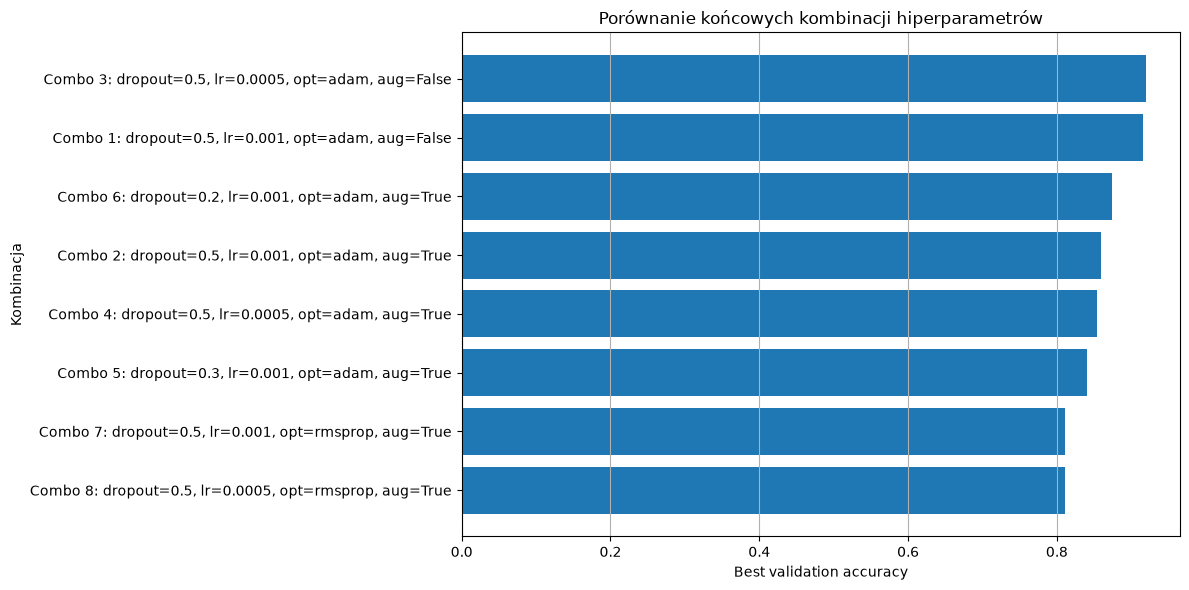

In [110]:
plt.figure(figsize=(12, 6))

plt.barh(
    combo_results_df["Model"],
    combo_results_df["Best val_accuracy"]
)

plt.title("Porównanie końcowych kombinacji hiperparametrów")
plt.xlabel("Best validation accuracy")
plt.ylabel("Kombinacja")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()
plt.show()

## Krzywe uczenia dla kombinacji

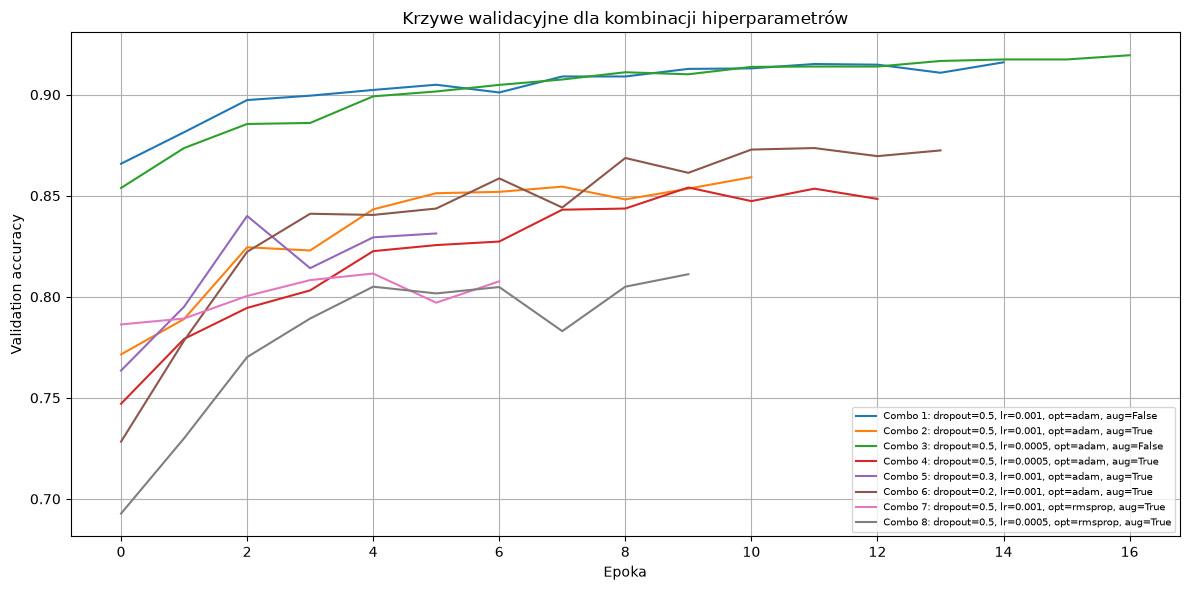

In [111]:
plt.figure(figsize=(12, 6))

for model_name, history in combo_histories.items():
    plt.plot(
        history.history["val_accuracy"],
        label=model_name
    )

plt.title("Krzywe walidacyjne dla kombinacji hiperparametrów")
plt.xlabel("Epoka")
plt.ylabel("Validation accuracy")
plt.legend(fontsize=7)
plt.grid(True)
plt.tight_layout()
plt.show()

## Wybór najlepszej kombinacji

In [112]:
# Pobieramy najlepszą kombinację z pierwszego wiersza posortowanej tabeli.

best_combo_name = combo_results_df.iloc[0]["Model"]
best_combo_model = combo_models[best_combo_name]

print("Najlepsza kombinacja hiperparametrów:")
print(best_combo_name)

print(
    f"Best validation accuracy: "
    f"{combo_results_df.iloc[0]['Best val_accuracy']:.4f}"
)

print(
    f"Best validation loss: "
    f"{combo_results_df.iloc[0]['Best val_loss']:.4f}"
)

Najlepsza kombinacja hiperparametrów:
Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False
Best validation accuracy: 0.9195
Best validation loss: 0.2446


# ZBIORCZE WYNIKI DLA WSZYSTKICH MODELI

In [ ]:
# Tworzymy DataFrame ze wszystkich wyników.

results_df = pd.DataFrame(results)

# Sortujemy modele od najlepszego do najgorszego.
results_df = results_df.sort_values(
    by="Best val_accuracy",
    ascending=False
)

# Resetujemy indeks.
results_df = results_df.reset_index(drop=True)

# Dodajemy ranking.
results_df.insert(
    0,
    "Ranking",
    range(1, len(results_df) + 1)
)

results_df

,Ranking,Model,Best val_accuracy,Best val_loss,Liczba epok
0,1,"Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug...",0.919500,0.244597,17
1,2,CNN Dropout 0.5,0.917250,0.247466,13
2,3,CNN Dropout 0.3,0.916167,0.263551,12
3,4,"Combo 1: dropout=0.5, lr=0.001, opt=adam, aug=...",0.916000,0.250951,15
4,5,CNN LR 0.0005,0.915083,0.243207,13
5,6,CNN LR 0.001,0.914167,0.260083,9
6,7,CNN Dropout 0.2,0.912583,0.252107,9
7,8,CNN optimizer adam,0.910583,0.259620,10
8,9,CNN + Dropout,0.909667,0.256314,8
9,10,CNN + BatchNormalization,0.908583,0.285947,7


# WYBÓR NAJLEPSZEGO MODELU

In [115]:
# Na podstawie validation accuracy wybrano model,
# który osiągnął najwyższą skuteczność na zbiorze walidacyjnym.
best_model_name = results_df.iloc[0]["Model"]

print("Najlepszy model:")
print(best_model_name)

Najlepszy model:
Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False


# EWALUACJA NA ZBIORZE TESTOWYM

In [ ]:
# Tworzymy słownik wszystkich wytrenowanych modeli.

all_models = {
    "Baseline": baseline_model,
    "MLP 128": mlp_128,
    "MLP Deep": mlp_deep,
    "CNN": cnn_model,
    "CNN + Dropout": cnn_dropout,
    "CNN + Augmentation": cnn_augmentation,
    "CNN + BatchNormalization": cnn_batchnorm
}

# Modele z tuningu Dropout.
for dropout_rate, model in dropout_models.items():
    all_models[f"CNN Dropout {dropout_rate}"] = model

# Modele z tuningu learning rate.
for lr, model in lr_models.items():
    all_models[f"CNN LR {lr}"] = model

# Modele z tuningu optymalizatora.
for optimizer_name, model in optimizer_models.items():
    all_models[f"CNN optimizer {optimizer_name}"] = model

# Modele z końcowych kombinacji hiperparametrów.
for model_name, model in combo_models.items():
    all_models[model_name] = model

In [120]:
# Pobieramy 3 najlepsze modele według validation accuracy.

top3 = results_df.head(3)

top3

,Ranking,Model,Best val_accuracy,Best val_loss,Liczba epok
0,1,"Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug...",0.919500,0.244597,17
1,2,CNN Dropout 0.5,0.917250,0.247466,13
2,3,CNN Dropout 0.3,0.916167,0.263551,12


In [122]:
# Lista do przechowywania wyników testowych.

test_results = []

# Przechodzimy po trzech najlepszych modelach.
for _, row in top3.iterrows():

    model_name = row["Model"]

    print(f"Testowanie modelu: {model_name}")

    # Pobieramy model ze słownika.
    model = all_models[model_name]

    # Obliczamy wynik na zbiorze testowym.
    test_loss, test_accuracy = model.evaluate(
        X_test_cnn,
        y_test,
        verbose=0
    )

    # Zapisujemy wyniki.
    test_results.append({
        "Model": model_name,
        "Validation accuracy": row["Best val_accuracy"],
        "Test accuracy": test_accuracy,
        "Test loss": test_loss
    })

Testowanie modelu: Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False
Testowanie modelu: CNN Dropout 0.5
Testowanie modelu: CNN Dropout 0.3


# TABELA WYNIKÓW EWALUACJI NA ZBIORZE TESTOWYM

In [123]:
test_results_df = pd.DataFrame(test_results)

test_results_df = test_results_df.sort_values(
    by="Test accuracy",
    ascending=False
)

test_results_df

,Model,Validation accuracy,Test accuracy,Test loss
0,"Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug...",0.919500,0.9094,0.260941
1,CNN Dropout 0.5,0.917250,0.9062,0.265241
2,CNN Dropout 0.3,0.916167,0.9046,0.280749


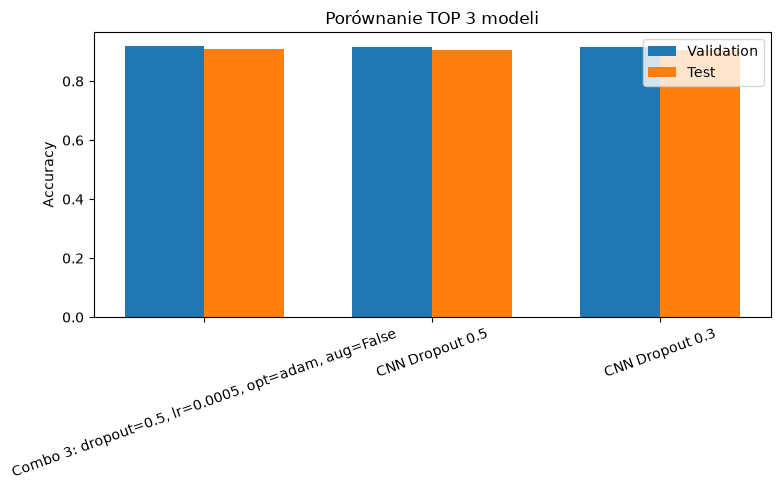

In [124]:
plt.figure(figsize=(8, 5))

x = np.arange(len(test_results_df))

width = 0.35

plt.bar(
    x - width/2,
    test_results_df["Validation accuracy"],
    width,
    label="Validation"
)

plt.bar(
    x + width/2,
    test_results_df["Test accuracy"],
    width,
    label="Test"
)

plt.xticks(
    x,
    test_results_df["Model"],
    rotation=20
)

plt.ylabel("Accuracy")
plt.title("Porównanie TOP 3 modeli")

plt.legend()

plt.tight_layout()
plt.show()

# WYBÓR NAJLEPSZEGO MODELU

In [129]:
# Wybieramy model, który uzyskał najwyższe accuracy na zbiorze testowym.

final_model_name = test_results_df.iloc[0]["Model"]

final_model = all_models[final_model_name]

print("Finalny model:")
print(final_model_name)

Finalny model:
Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False


## Predykcje finalnego modelu

In [130]:
# Model zwraca prawdopodobieństwa dla każdej z 10 klas.
# Za ostateczną predykcję przyjmujemy klasę z najwyższym prawdopodobieństwem.

y_pred_probs = final_model.predict(X_test_cnn)

y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


## Raport klasyfikacji

In [ ]:

# Raport klasyfikacji pokazuje wyniki osobno dla każdej klasy:
#
# Precision (precyzja)
# Spośród wszystkich przykładów przypisanych przez model do danej klasy,
# jaki procent rzeczywiście należał do tej klasy.
#
# Recall (czułość)
# Spośród wszystkich rzeczywistych przykładów danej klasy,
# jaki procent został poprawnie wykryty przez model.
#
# F1-score
# Średnia harmoniczna precision i recall.
# Jest dobrą miarą ogólnej jakości klasyfikacji dla danej klasy.
#
# Support
# Liczba przykładów danej klasy występujących w zbiorze testowym.

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.86      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.88      0.86      0.87      1000
       Dress       0.90      0.91      0.91      1000
        Coat       0.86      0.84      0.85      1000
      Sandal       0.98      0.97      0.98      1000
       Shirt       0.71      0.77      0.74      1000
     Sneaker       0.96      0.96      0.96      1000
         Bag       0.99      0.97      0.98      1000
  Ankle boot       0.96      0.97      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



## Macierz pomyłek

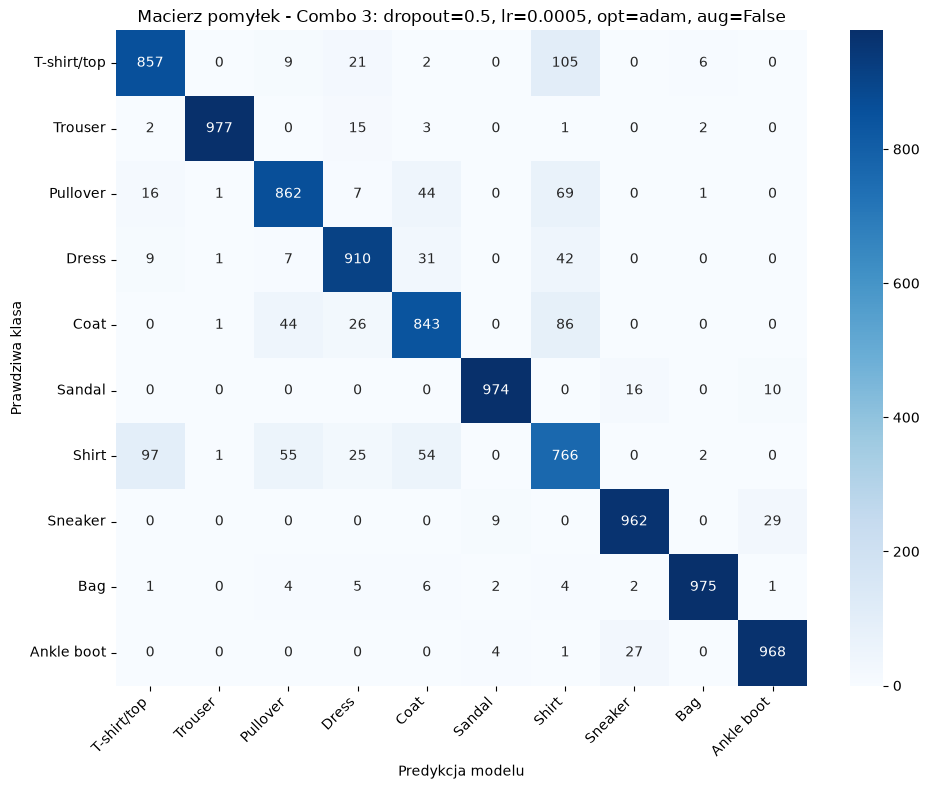

In [132]:
# Macierz pomyłek pokazuje, które klasy model rozpoznaje poprawnie,
# a które najczęściej myli ze sobą.

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(f"Macierz pomyłek - {final_model_name}")
plt.xlabel("Predykcja modelu")
plt.ylabel("Prawdziwa klasa")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Accuracy dla każdej klasy

In [133]:
# Zamieniamy classification_report na DataFrame,
# żeby łatwiej analizować wyniki dla pojedynczych klas.

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
T-shirt/top,0.872709,0.8570,0.864783,1000.0000
Trouser,0.995923,0.9770,0.986371,1000.0000
Pullover,0.878695,0.8620,0.870268,1000.0000
Dress,0.901883,0.9100,0.905923,1000.0000
Coat,0.857579,0.8430,0.850227,1000.0000
Sandal,0.984833,0.9740,0.979387,1000.0000
Shirt,0.713222,0.7660,0.738669,1000.0000
Sneaker,0.955313,0.9620,0.958645,1000.0000
Bag,0.988844,0.9750,0.981873,1000.0000
Ankle boot,0.960317,0.9680,0.964143,1000.0000


## Wykres F1-score dla klas

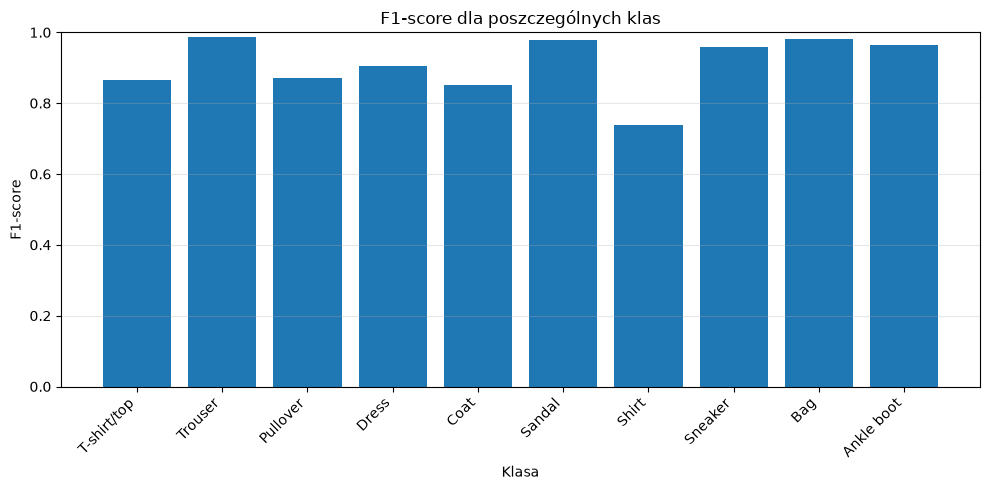

In [134]:
# F1-score łączy precision i recall.
# Dzięki temu dobrze pokazuje, z którymi klasami model radzi sobie najlepiej i najgorzej.

classes_report_df = report_df.iloc[:10].copy()

plt.figure(figsize=(10, 5))

plt.bar(
    classes_report_df.index,
    classes_report_df["f1-score"]
)

plt.title("F1-score dla poszczególnych klas")
plt.xlabel("Klasa")
plt.ylabel("F1-score")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Analiza błędnych klasyfikacji

In [135]:
# Szukamy indeksów obrazów, które zostały sklasyfikowane błędnie.

wrong_indices = np.where(y_pred != y_test)[0]

print("Liczba błędnych klasyfikacji:", len(wrong_indices))
print("Liczba wszystkich przykładów testowych:", len(y_test))
print(f"Odsetek błędów: {len(wrong_indices) / len(y_test):.4f}")

Liczba błędnych klasyfikacji: 906
Liczba wszystkich przykładów testowych: 10000
Odsetek błędów: 0.0906


## Przykładowe błędne klasyfikacje

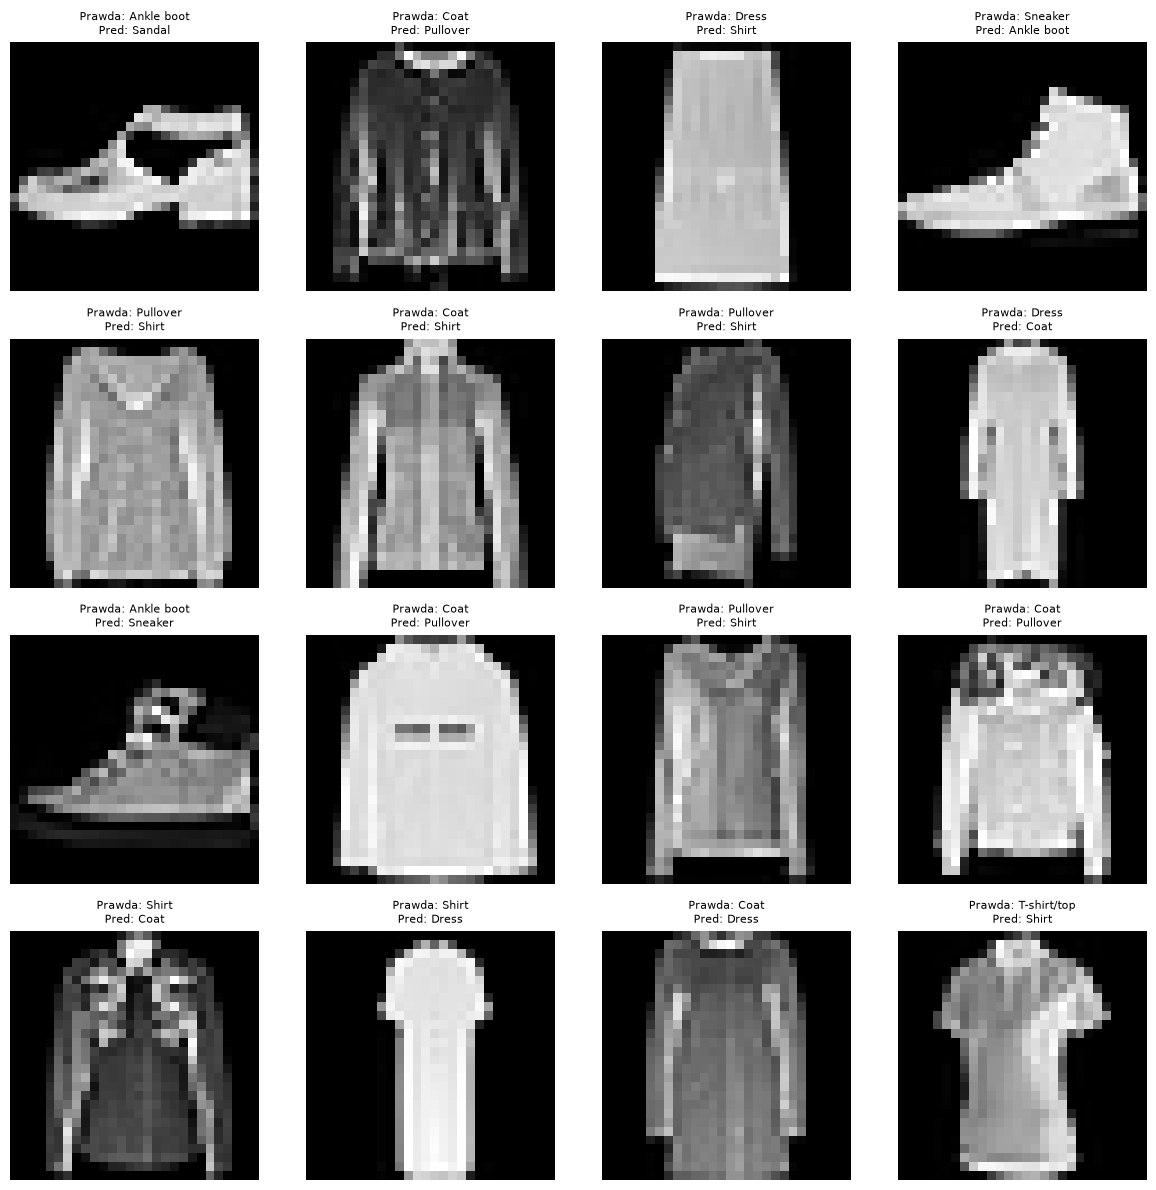

In [136]:
# Wyświetlamy przykładowe błędy modelu.
# Pozwala to zobaczyć, czy pomyłki są zrozumiałe wizualnie.

plt.figure(figsize=(12, 12))

for i, idx in enumerate(wrong_indices[:16]):

    plt.subplot(4, 4, i + 1)

    plt.imshow(X_test[idx], cmap="gray")

    true_label = class_names[y_test[idx]]
    predicted_label = class_names[y_pred[idx]]

    plt.title(
        f"Prawda: {true_label}\nPred: {predicted_label}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Najczęściej mylone klasy

In [ ]:

# Tworzymy kopię macierzy pomyłek.
# Na przekątnej znajdują się poprawne klasyfikacje,
# dlatego ustawiamy je na 0, aby analizować tylko błędy modelu.

cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)


# Lista, w której zapiszemy wszystkie błędne klasyfikacje.
mistakes = []


# Przechodzimy po wszystkich parach:
# prawdziwa klasa to klasa przewidziana przez model.
for true_class in range(len(class_names)):

    for predicted_class in range(len(class_names)):

        count = cm_errors[true_class, predicted_class]

        # Zapisujemy tylko te przypadki, w których wystąpiła pomyłka.
        if count > 0:

            mistakes.append({
                "Prawdziwa klasa": class_names[true_class],
                "Predykcja modelu": class_names[predicted_class],
                "Liczba pomyłek": count
            })


# Zamieniamy listę pomyłek na DataFrame.
mistakes_df = pd.DataFrame(mistakes)


# Sortujemy pomyłki od najczęstszych do najrzadszych.
mistakes_df = mistakes_df.sort_values(
    by="Liczba pomyłek",
    ascending=False
)


# Resetujemy indeks, żeby tabela była uporządkowana od 0.
mistakes_df = mistakes_df.reset_index(drop=True)


# Wybieramy 10 najczęstszych pomyłek.
top_mistakes = mistakes_df.head(10).copy()


# Ustawiamy indeks od 1, żeby pełnił funkcję rankingu.
top_mistakes.index = range(1, len(top_mistakes) + 1)

top_mistakes

,Prawdziwa klasa,Predykcja modelu,Liczba pomyłek
1,T-shirt/top,Shirt,105
2,Shirt,T-shirt/top,97
3,Coat,Shirt,86
4,Pullover,Shirt,69
5,Shirt,Pullover,55
6,Shirt,Coat,54
7,Coat,Pullover,44
8,Pullover,Coat,44
9,Dress,Shirt,42
10,Dress,Coat,31


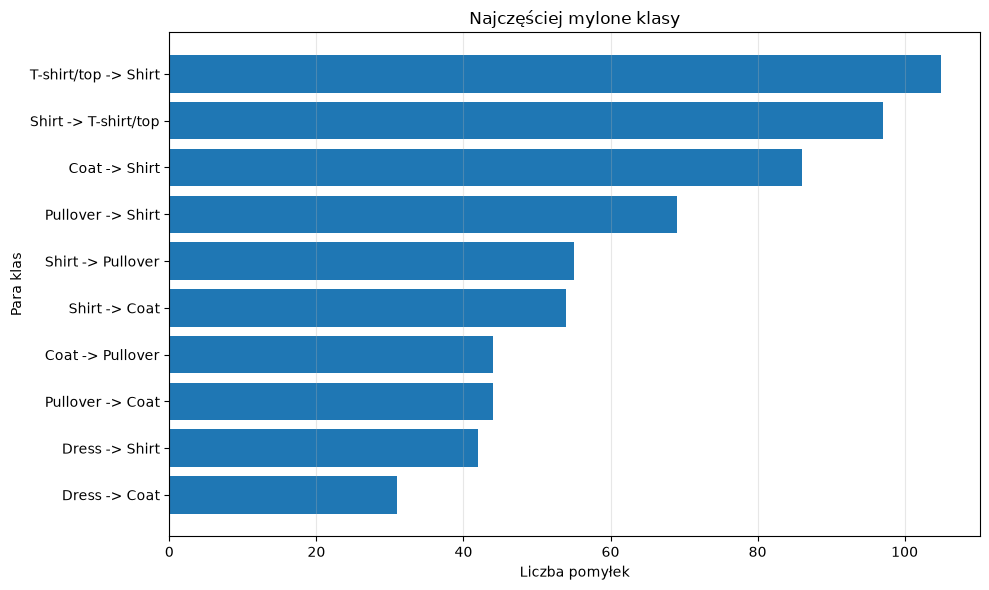

In [ ]:
# Tworzymy etykietę pokazującą kierunek pomyłki:
# prawdziwa klasa to predykcja modelu.

top_mistakes_plot = top_mistakes.copy()

top_mistakes_plot["Para klas"] = (
    top_mistakes_plot["Prawdziwa klasa"]
    + " -> "
    + top_mistakes_plot["Predykcja modelu"]
)


plt.figure(figsize=(10, 6))

plt.barh(
    top_mistakes_plot["Para klas"],
    top_mistakes_plot["Liczba pomyłek"]
)

plt.title("Najczęściej mylone klasy")
plt.xlabel("Liczba pomyłek")
plt.ylabel("Para klas")

# Najczęstsza pomyłka na górze.
plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# Ranking najczęściej mylonych klas pozwala określić,
# które kategorie ubrań są najbardziej podobne z punktu widzenia modelu.
#
# Wysoka liczba pomyłek pomiędzy dwiema klasami oznacza,
# że obrazy tych kategorii mają podobne cechy wizualne
# i są trudniejsze do rozróżnienia.
#
# Dla zbioru Fashion-MNIST najczęściej obserwuje się pomyłki
# pomiędzy klasami Shirt, T-shirt/top, Coat oraz Pullover,
# ponieważ ich kształty i kontury są do siebie zbliżone.